Mounting Google Drive

In [ ]:
# Mount Google Drive.
# force_remount=True ensures a fresh connection even if a session
# was already active, preventing stale/broken mount issues.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Setting up required libraries

In [ ]:
# Standard library
import os
import random
import logging
from collections import defaultdict

# Image processing
from PIL import Image, ImageDraw

# Visualization
import matplotlib.pyplot as plt

# Logging config: writes timestamp | level | message to console
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[logging.StreamHandler()]
)

Data Discovery

In [ ]:
# Project root — the only path you ever need to edit manually
BASE = '/content/drive/MyDrive/2026_white_lesion_detection_project'

# --- Input (read only, never write here) ---
RAW_IMAGES   = os.path.join(BASE, '01_raw_images_rgb')
ANNOTATION   = os.path.join(BASE, 'annotation.xml')

# --- Processing steps ---
GRAY_IMAGES  = os.path.join(BASE, '02_grayscale')
CROP_IMAGES  = os.path.join(BASE, '03_cropped_images')
CROP_MASKS   = os.path.join(BASE, '04_cropped_masks')

# --- Masks ---
MASKS_RAW    = os.path.join(BASE, '05_masks_generated')

# --- Final dataset (model input) ---
DATASET      = os.path.join(BASE, '06_dataset')
TRAIN_IMAGES = os.path.join(DATASET, 'train', 'images')
TRAIN_MASKS  = os.path.join(DATASET, 'train', 'masks')
VAL_IMAGES   = os.path.join(DATASET, 'val',   'images')
VAL_MASKS    = os.path.join(DATASET, 'val',   'masks')
TEST_IMAGES  = os.path.join(DATASET, 'test',  'images')
TEST_MASKS   = os.path.join(DATASET, 'test',  'masks')

# --- Outputs ---
OUTPUTS      = os.path.join(BASE, '07_outputs')
MODELS       = os.path.join(OUTPUTS, 'models')
PREDICTIONS  = os.path.join(OUTPUTS, 'predictions')
LOGS         = os.path.join(OUTPUTS, 'logs')

# Verify input paths exist
print("Input paths:")
for name, path in [('BASE', BASE), ('RAW_IMAGES', RAW_IMAGES), ('ANNOTATION', ANNOTATION)]:
    status = '✓' if os.path.exists(path) else '✗  not found'
    print(f'  {status}  {name}')

# Create all output folders if they don't exist yet
output_folders = [
    GRAY_IMAGES, CROP_IMAGES, CROP_MASKS, MASKS_RAW,
    TRAIN_IMAGES, TRAIN_MASKS, VAL_IMAGES, VAL_MASKS,
    TEST_IMAGES, TEST_MASKS, MODELS, PREDICTIONS, LOGS
]

created = 0
for folder in output_folders:
    if not os.path.exists(folder):
        os.makedirs(folder)
        created += 1

print(f"\nOutput folders: {created} created, {len(output_folders) - created} already existed")

Input paths:
  ✓  BASE
  ✓  RAW_IMAGES
  ✓  ANNOTATION

Output folders: 0 created, 13 already existed


In [ ]:
# Collect basic file info: count and size of each image
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

image_files = [
    f for f in os.listdir(RAW_IMAGES)
    if f.lower().endswith(image_extensions)
]
image_files.sort()

file_sizes_kb = []
unreadable = []

for fname in image_files:
    path = os.path.join(RAW_IMAGES, fname)
    try:
        size_kb = os.path.getsize(path) / 1024
        file_sizes_kb.append(size_kb)
    except Exception as e:
        unreadable.append((fname, str(e)))

print(f"Total images found : {len(image_files)}")
print(f"Unreadable files   : {len(unreadable)}")
print(f"File size — min    : {min(file_sizes_kb):.1f} KB")
print(f"File size — max    : {max(file_sizes_kb):.1f} KB")
print(f"File size — mean   : {sum(file_sizes_kb)/len(file_sizes_kb):.1f} KB")

if unreadable:
    print("\nUnreadable files:")
    for fname, err in unreadable:
        print(f"  {fname}: {err}")

Total images found : 303
Unreadable files   : 0
File size — min    : 1347.9 KB
File size — max    : 1618.9 KB
File size — mean   : 1499.6 KB


In [ ]:
# Check image dimensions and color modes across the full dataset.
# We open each image but do NOT load pixel data (draft mode) — fast even for large sets.

dimension_counts = defaultdict(int)
mode_counts = defaultdict(int)
problem_files = []

for fname in image_files:
    path = os.path.join(RAW_IMAGES, fname)
    try:
        with Image.open(path) as img:
            dimension_counts[img.size] += 1   # img.size = (width, height)
            mode_counts[img.mode] += 1
    except Exception as e:
        problem_files.append((fname, str(e)))

# Dimensions
print("Image dimensions (width x height) — sorted by frequency:")
for dims, count in sorted(dimension_counts.items(), key=lambda x: -x[1]):
    print(f"  {dims[0]} x {dims[1]}  →  {count} image(s)")

# Color modes
print(f"\nColor modes:")
for mode, count in sorted(mode_counts.items(), key=lambda x: -x[1]):
    print(f"  {mode}  →  {count} image(s)")

# Flag anything unexpected
if len(dimension_counts) > 1:
    print("\n⚠  Mixed dimensions detected — we will need to handle this before cropping.")
if 'RGB' in mode_counts and 'L' in mode_counts:
    print("⚠  Mixed color modes detected — we will standardize during processing.")
if not problem_files:
    print("\n✓  All files opened successfully.")
else:
    print(f"\n⚠  {len(problem_files)} file(s) could not be opened:")
    for fname, err in problem_files:
        print(f"  {fname}: {err}")

Image dimensions (width x height) — sorted by frequency:
  3000 x 1500  →  303 image(s)

Color modes:
  RGBA  →  303 image(s)

✓  All files opened successfully.


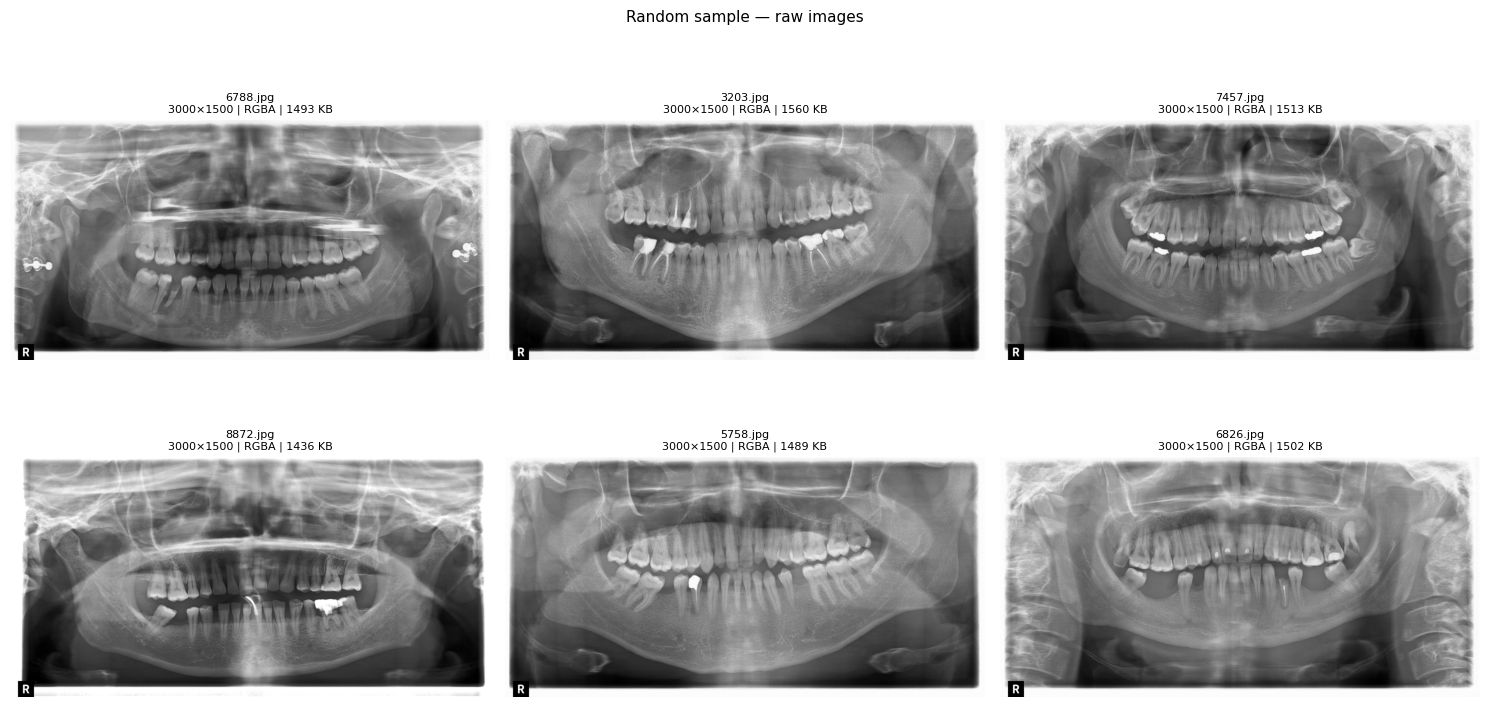

In [ ]:
# Display a random sample of 6 images with their metadata.
# Goal: visually confirm the dataset looks consistent.
# Run this cell multiple times to see different samples.

sample_size = 6
sample = random.sample(image_files, min(sample_size, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, fname in enumerate(sample):
    path = os.path.join(RAW_IMAGES, fname)
    with Image.open(path) as img:
        width, height = img.size
        mode = img.mode
        size_kb = os.path.getsize(path) / 1024
        axes[i].imshow(img)
        axes[i].set_title(
            f'{fname}\n{width}×{height} | {mode} | {size_kb:.0f} KB',
            fontsize=8
        )
        axes[i].axis('off')

plt.suptitle('Random sample — raw images', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Final summary of data discovery findings.
# This becomes a reference point before we start any processing.

total = len(image_files)
unique_dims = len(dimension_counts)
unique_modes = len(mode_counts)
dominant_dim = max(dimension_counts, key=dimension_counts.get)
dominant_mode = max(mode_counts, key=mode_counts.get)

print("=" * 45)
print("  DATA DISCOVERY SUMMARY")
print("=" * 45)
print(f"  Total images       : {total}")
print(f"  Unique dimensions  : {unique_dims}  (dominant: {dominant_dim[0]}×{dominant_dim[1]})")
print(f"  Color modes        : {unique_modes}  (dominant: {dominant_mode})")
print(f"  File size range    : {min(file_sizes_kb):.0f} – {max(file_sizes_kb):.0f} KB")
print(f"  Unreadable files   : {len(unreadable)}")
print("=" * 45)

# Processing decisions based on findings
print("\n  Processing decisions:")
if unique_dims == 1:
    print("  ✓ All images same size — fixed crop is safe to apply.")
else:
    print("  ⚠ Mixed sizes — review before applying fixed crop.")
if dominant_mode == 'RGB':
    print("  ✓ Images are RGB — will convert to grayscale during processing.")
elif dominant_mode == 'L':
    print("  ✓ Images already grayscale — no conversion needed.")
else:
    print(f"  ⚠ Unexpected color mode ({dominant_mode}) — review before processing.")

  DATA DISCOVERY SUMMARY
  Total images       : 303
  Unique dimensions  : 1  (dominant: 3000×1500)
  Color modes        : 1  (dominant: RGBA)
  File size range    : 1348 – 1619 KB
  Unreadable files   : 0

  Processing decisions:
  ✓ All images same size — fixed crop is safe to apply.
  ⚠ Unexpected color mode (RGBA) — review before processing.


## 4. Image Processing — Step 1: Convert RGBA to Grayscale

All 303 raw images are RGBA (4 channels).
We convert to grayscale (L, 1 channel) for two reasons:
- The alpha channel carries no useful information for lesion detection
- Grayscale reduces input complexity, which helps the model focus on intensity patterns

Output folder: 02_grayscale



In [ ]:
# Convert all raw RGBA images to grayscale and save to 02_grayscale.
# We use PIL's convert('L') which handles alpha stripping internally.
# Original files in 01_raw_images_rgb are never modified.

converted = 0
skipped = 0
errors = []

for fname in image_files:
    src_path = os.path.join(RAW_IMAGES, fname)
    dst_path = os.path.join(GRAY_IMAGES, fname)

    # Skip if already converted (useful if cell is re-run)
    if os.path.exists(dst_path):
        skipped += 1
        continue

    try:
        with Image.open(src_path) as img:
            gray = img.convert('L')
            gray.save(dst_path)
            converted += 1
    except Exception as e:
        errors.append((fname, str(e)))

print(f"Converted : {converted}")
print(f"Skipped   : {skipped}  (already existed)")
print(f"Errors    : {len(errors)}")

if errors:
    for fname, err in errors:
        print(f"  ✗ {fname}: {err}")
else:
    print("\n✓ All images converted successfully.")

Converted : 0
Skipped   : 303  (already existed)
Errors    : 0

✓ All images converted successfully.


## 5. Mask Generation

For each image we generate a binary mask (same size as the image):
- White (255) = lesion area
- Black (0)   = background

Source: annotation.xml (CVAT polyline annotations)
Output: 05_masks_generated

Images with no annotation in the XML receive an all-black mask
(negative samples — the model needs to learn "no lesion" cases too).

In [ ]:
import xml.etree.ElementTree as ET

# Parse the annotation XML
tree = ET.parse(ANNOTATION)
root = tree.getroot()

# Build a dictionary: image filename → list of point lists
# Each image can have multiple polylines (multiple lesions)
annotations = defaultdict(list)

for image_tag in root.findall('image'):
    image_name = image_tag.get('name')
    for polyline in image_tag.findall('polyline'):
        raw_points = polyline.get('points')
        # Points format: "x1,y1;x2,y2;x3,y3;..."
        points = [
            tuple(map(float, p.split(',')))
            for p in raw_points.split(';')
        ]
        annotations[image_name].append(points)

print(f"Images with annotations in XML : {len(annotations)}")

# Get all grayscale images
gray_files = sorted([
    f for f in os.listdir(GRAY_IMAGES)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])
print(f"Total grayscale images         : {len(gray_files)}")

# Generate masks
generated   = 0
negative    = 0
skipped     = 0
errors      = []

for fname in gray_files:
    # Mask filename: same name as image but saved as .png
    mask_fname = os.path.splitext(fname)[0] + '.png'
    dst_path   = os.path.join(MASKS_RAW, mask_fname)

    # Skip if already exists (safe to re-run)
    if os.path.exists(dst_path):
        skipped += 1
        continue

    try:
        # Create black canvas — same size as original images
        mask = Image.new('L', (3000, 1500), 0)
        draw = ImageDraw.Draw(mask)

        if fname in annotations:
            # Draw each lesion polygon as filled white
            for points in annotations[fname]:
                draw.polygon(points, outline=255, fill=255)
            generated += 1
        else:
            # No annotation → all-black mask (negative sample)
            negative += 1

        mask.save(dst_path)

    except Exception as e:
        errors.append((fname, str(e)))

print(f"\nMasks generated (with lesion)  : {generated}")
print(f"Masks generated (negative)     : {negative}")
print(f"Skipped (already existed)      : {skipped}")
print(f"Errors                         : {len(errors)}")

if errors:
    for fname, err in errors:
        print(f"  ✗ {fname}: {err}")
else:
    print("\n✓ All masks generated successfully.")

Images with annotations in XML : 298
Total grayscale images         : 303

Masks generated (with lesion)  : 0
Masks generated (negative)     : 0
Skipped (already existed)      : 303
Errors                         : 0

✓ All masks generated successfully.


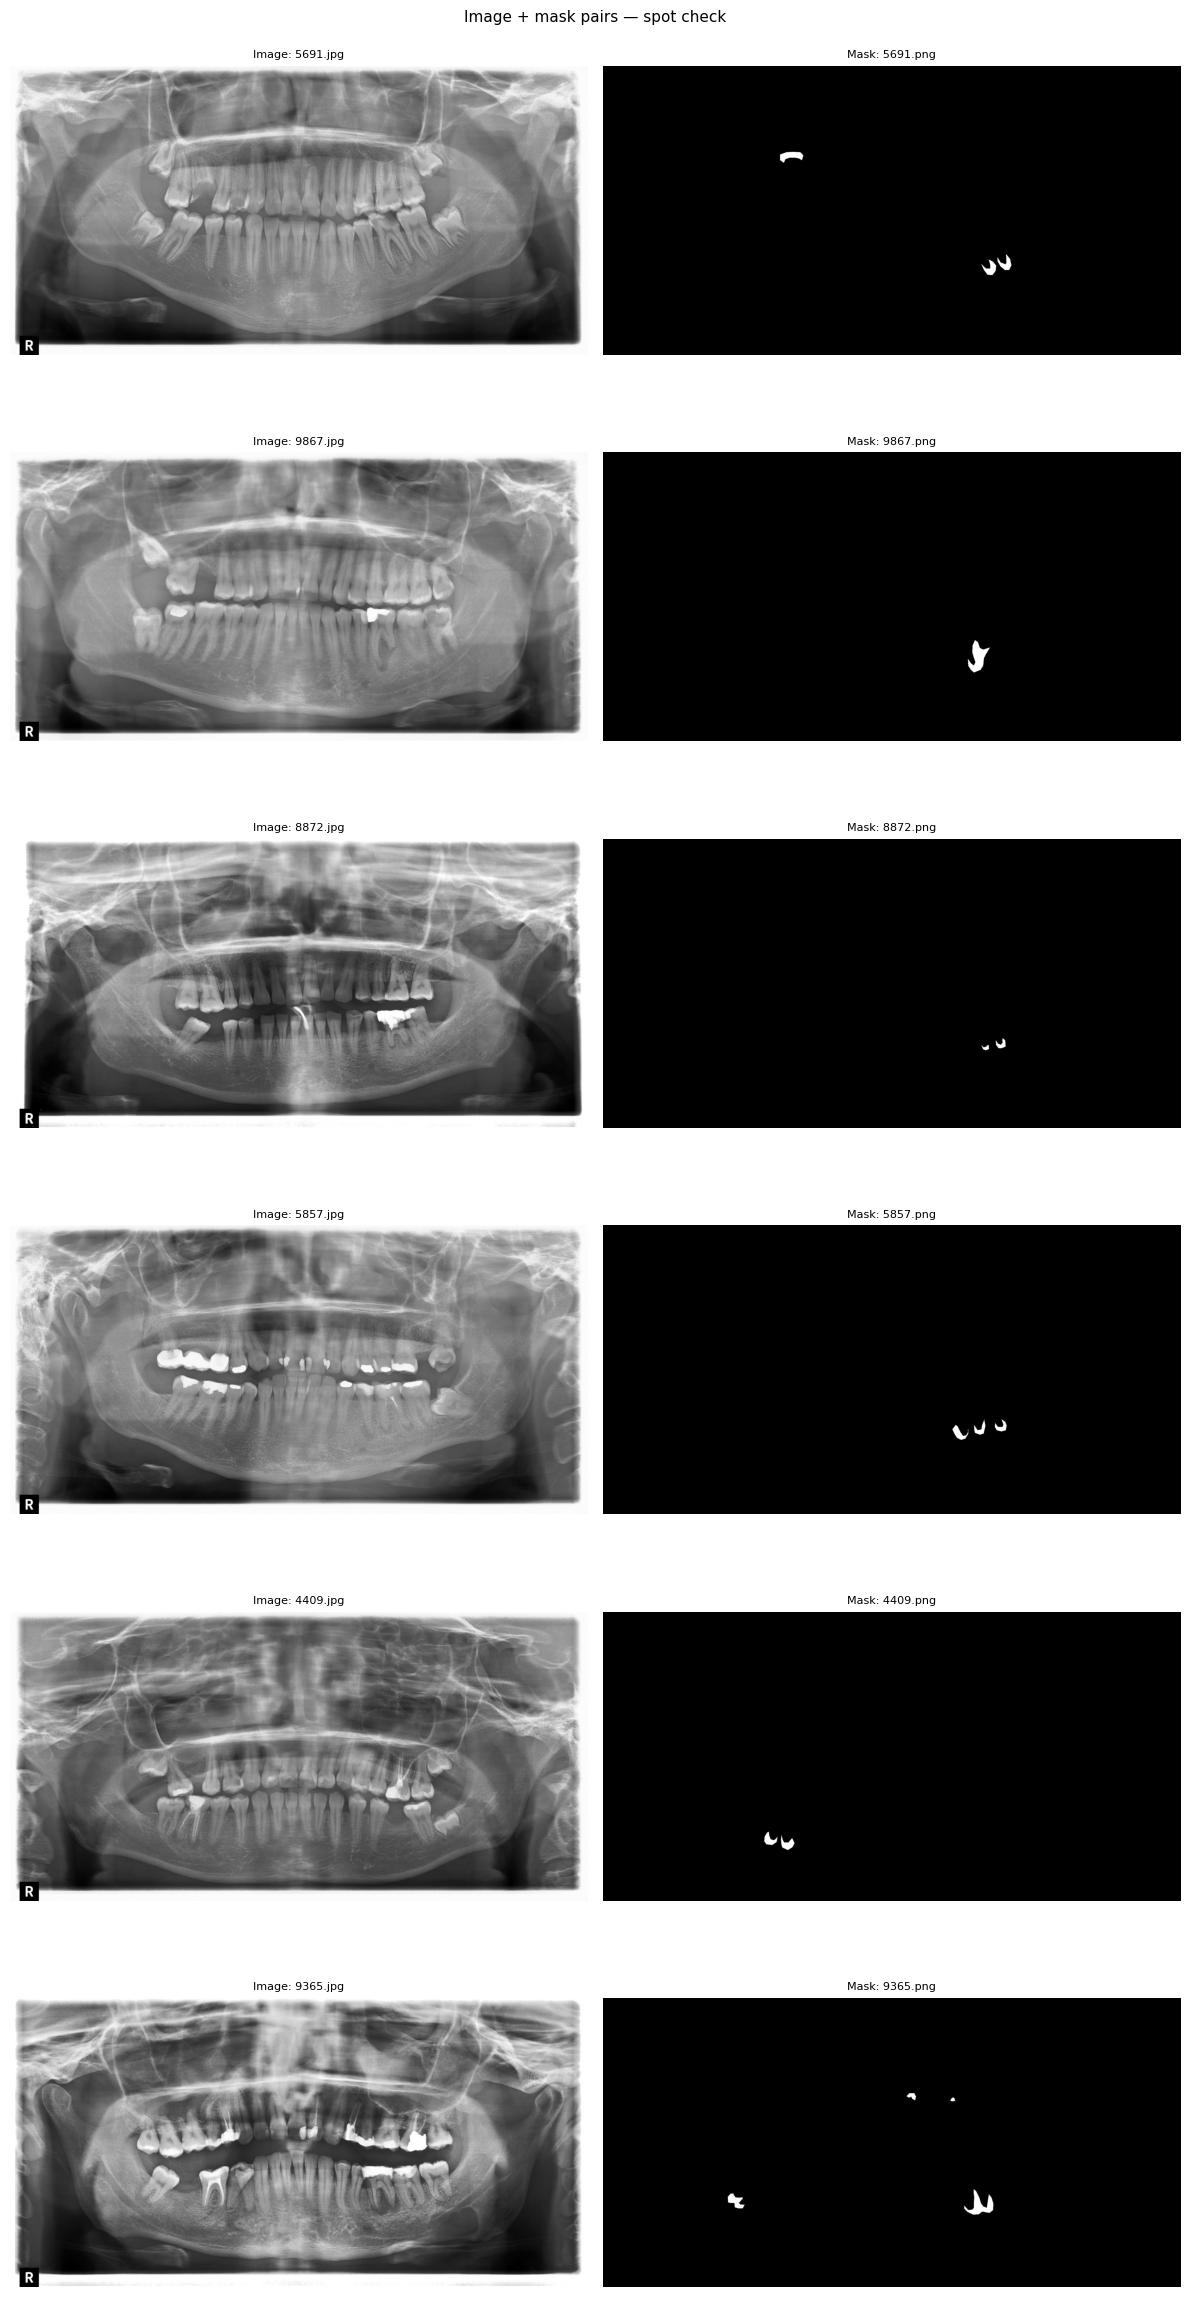

In [ ]:
# Display 6 random image + mask pairs side by side.
# Confirm that white regions in the mask align with lesions in the image.

mask_files = sorted([
    f for f in os.listdir(MASKS_RAW)
    if f.lower().endswith('.png')
])

sample = random.sample(mask_files, min(6, len(mask_files)))

fig, axes = plt.subplots(6, 2, figsize=(12, 24))

for i, mask_fname in enumerate(sample):
    # Corresponding image has same name but .jpg extension
    img_fname = os.path.splitext(mask_fname)[0] + '.jpg'
    img_path  = os.path.join(GRAY_IMAGES, img_fname)
    mask_path = os.path.join(MASKS_RAW, mask_fname)

    with Image.open(img_path) as img, Image.open(mask_path) as mask:
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f'Image: {img_fname}', fontsize=8)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title(f'Mask: {mask_fname}', fontsize=8)
        axes[i, 1].axis('off')

plt.suptitle('Image + mask pairs — spot check', fontsize=11)
plt.tight_layout()
plt.show()

### Overlay check — use this anytime to verify a specific image+mask pair (Change fname to inspect any image)

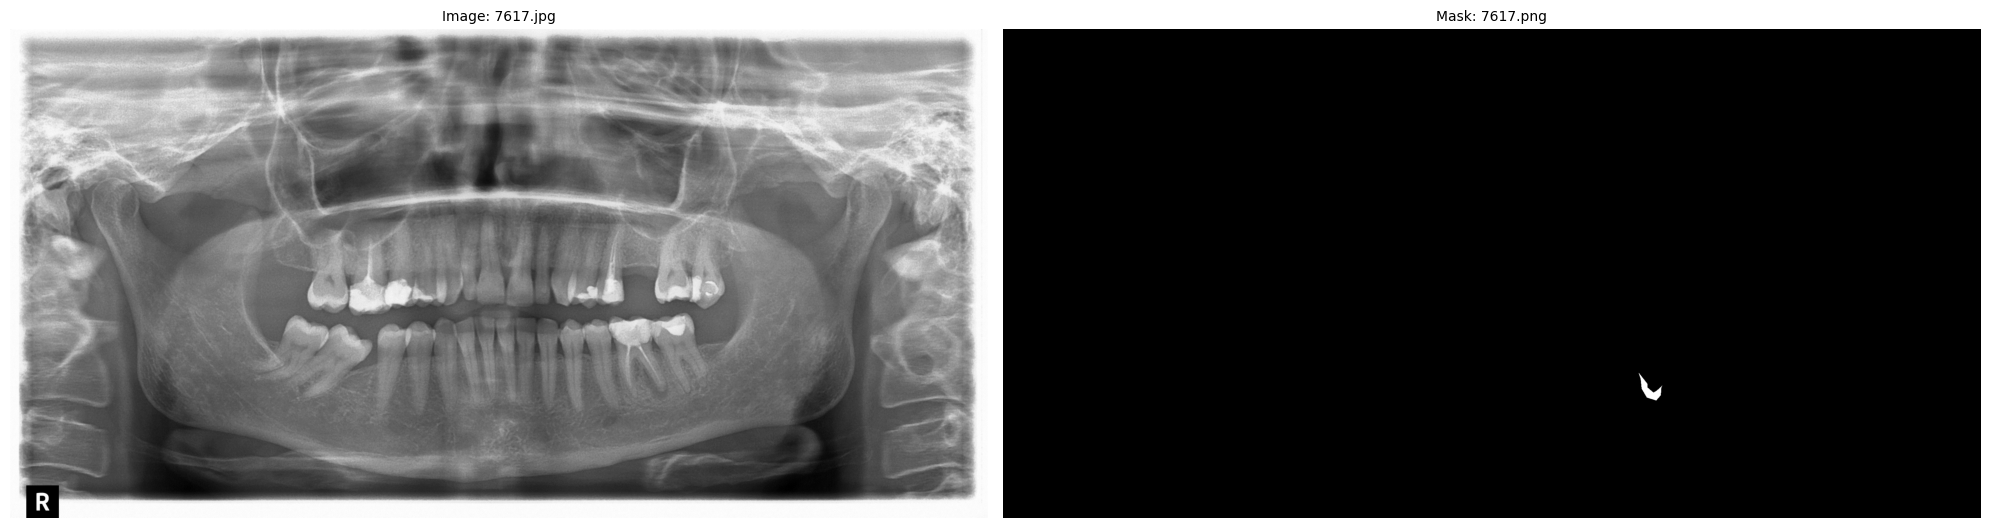

In [ ]:
# Zoom in on a specific image+mask pair for closer inspection
fname = '7617.jpg'
mask_fname = '7617.png'

img_path  = os.path.join(GRAY_IMAGES, fname)
mask_path = os.path.join(MASKS_RAW, mask_fname)

with Image.open(img_path) as img, Image.open(mask_path) as mask:
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Image: 7617.jpg', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mask: 7617.png', fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

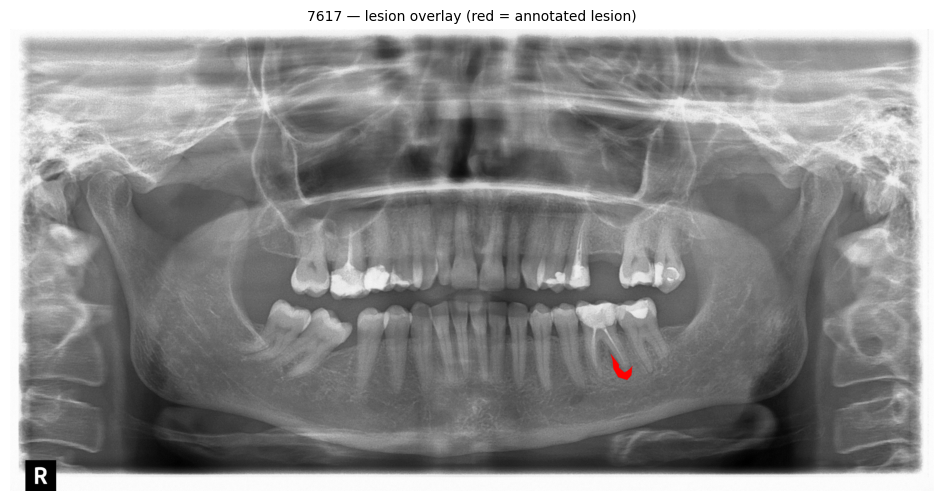

In [ ]:
import numpy as np

with Image.open(img_path) as img, Image.open(mask_path) as mask:
    img_rgb = img.convert('RGB')
    img_array  = np.array(img_rgb)
    mask_array = np.array(mask)

    # Highlight lesion pixels in red
    img_array[mask_array > 127] = [255, 0, 0]

    overlay = Image.fromarray(img_array)

    plt.figure(figsize=(20, 6))
    plt.imshow(overlay)
    plt.title('7617 — lesion overlay (red = annotated lesion)', fontsize=10)
    plt.axis('off')
    plt.show()

Understanding location of annotations

In [ ]:
# Analyze all annotation coordinates across the entire dataset.
# Goal: find the min/max x and y values of all lesion points
# so we can define a crop area that contains every single annotation.

import xml.etree.ElementTree as ET

tree = ET.parse(ANNOTATION)
root = tree.getroot()

all_x = []
all_y = []

for image_tag in root.findall('image'):
    for polyline in image_tag.findall('polyline'):
        raw_points = polyline.get('points')
        for p in raw_points.split(';'):
            x, y = map(float, p.split(','))
            all_x.append(x)
            all_y.append(y)

print(f"Total annotation points analyzed: {len(all_x)}")
print()
print(f"X range — min: {min(all_x):.0f}  max: {max(all_x):.0f}")
print(f"Y range — min: {min(all_y):.0f}  max: {max(all_y):.0f}")
print()
print(f"Image size: 3000 x 1500")
print()
print(f"Suggested crop with 50px safety margin:")
print(f"  X: {max(0, min(all_x)-50):.0f} → {min(3000, max(all_x)+50):.0f}")
print(f"  Y: {max(0, min(all_y)-50):.0f} → {min(1500, max(all_y)+50):.0f}")

Total annotation points analyzed: 9790

X range — min: 592  max: 2354
Y range — min: 287  max: 1288

Image size: 3000 x 1500

Suggested crop with 50px safety margin:
  X: 542 → 2404
  Y: 237 → 1338


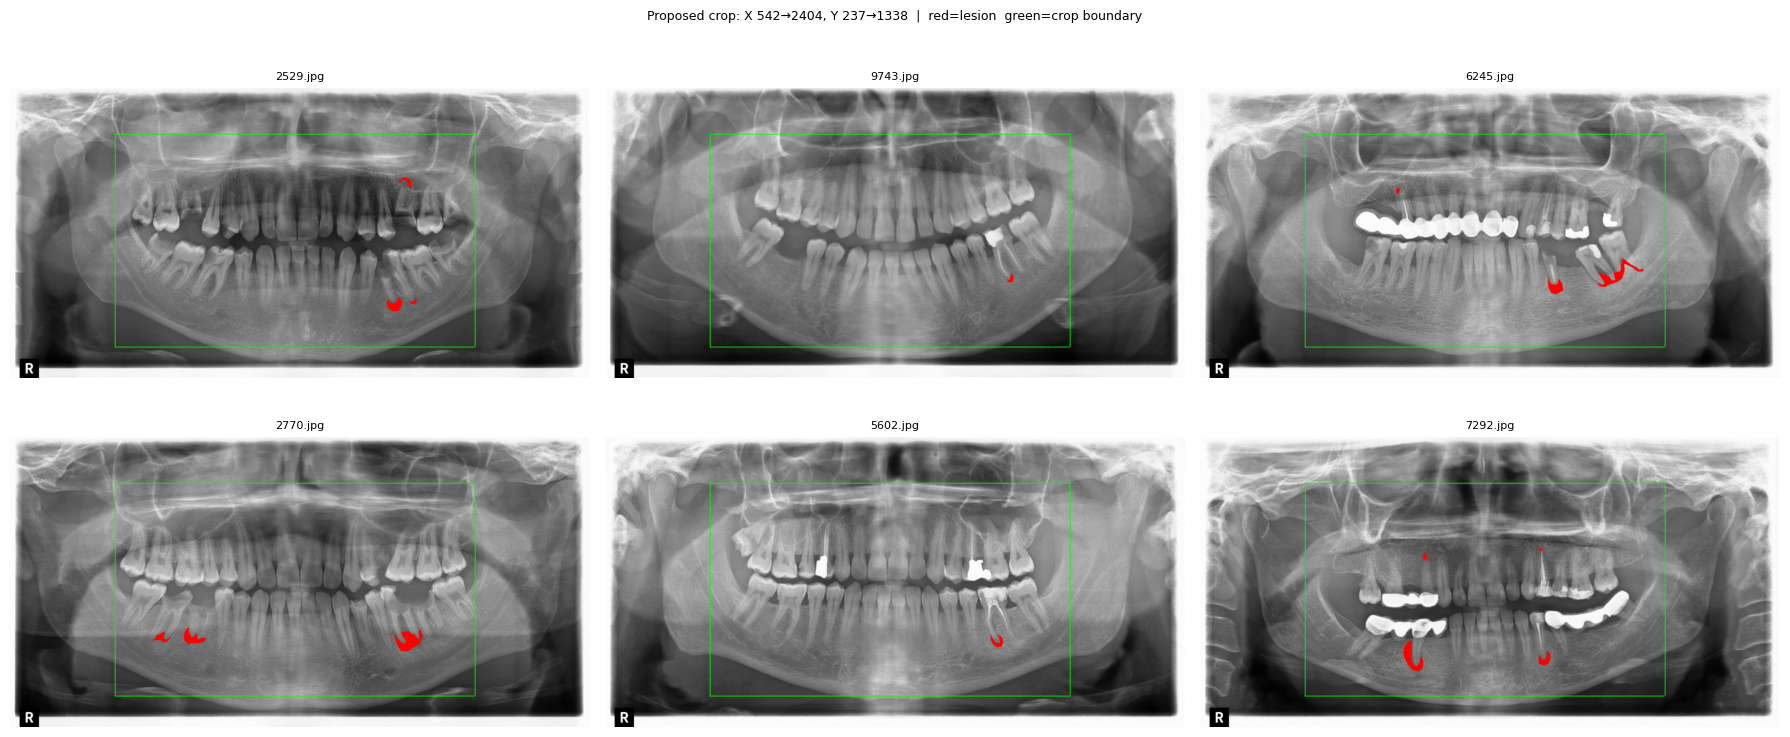

In [ ]:
# Draw the proposed crop rectangle on 6 random images.
# Green box = proposed crop area.
# Verify visually that all teeth are inside the box
# and that we're cutting away only irrelevant areas.

import numpy as np

# Proposed crop coordinates (from annotation analysis + 50px margin)
CROP_X1, CROP_X2 = 542, 2404
CROP_Y1, CROP_Y2 = 237, 1338

sample = random.sample(gray_files, min(6, len(gray_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, fname in enumerate(sample):
    img_path  = os.path.join(GRAY_IMAGES, fname)
    mask_fname = os.path.splitext(fname)[0] + '.png'
    mask_path = os.path.join(MASKS_RAW, mask_fname)

    with Image.open(img_path) as img, Image.open(mask_path) as mask:
        # Convert to RGB so we can draw colored rectangle
        img_rgb   = np.array(img.convert('RGB'))
        mask_arr  = np.array(mask)

        # Highlight lesion in red
        img_rgb[mask_arr > 127] = [255, 0, 0]

        # Draw crop rectangle in green (4px border)
        thickness = 4
        img_rgb[CROP_Y1:CROP_Y1+thickness, CROP_X1:CROP_X2] = [0, 255, 0]  # top
        img_rgb[CROP_Y2:CROP_Y2+thickness, CROP_X1:CROP_X2] = [0, 255, 0]  # bottom
        img_rgb[CROP_Y1:CROP_Y2, CROP_X1:CROP_X1+thickness] = [0, 255, 0]  # left
        img_rgb[CROP_Y1:CROP_Y2, CROP_X2:CROP_X2+thickness] = [0, 255, 0]  # right

        axes[i].imshow(img_rgb)
        axes[i].set_title(fname, fontsize=8)
        axes[i].axis('off')

plt.suptitle(
    f'Proposed crop: X {CROP_X1}→{CROP_X2}, Y {CROP_Y1}→{CROP_Y2}  |  red=lesion  green=crop boundary',
    fontsize=9
)
plt.tight_layout()
plt.show()

## 6. Image Processing — Step 2: Crop

Crop coordinates determined from annotation bounding box analysis.
All 298 lesion annotations fall within this region with a 50px safety margin.

Crop area: X 542→2404, Y 237→1338
Result size: 1862 x 1101 pixels

Both images and masks are cropped with identical coordinates
to ensure perfect alignment is maintained.

Output folders: 03_cropped_images, 04_cropped_masks

In [ ]:
# Crop coordinates — derived from annotation bounding box + 50px margin
# Do not change these without re-running the annotation analysis cell.
CROP_X1, CROP_X2 = 542, 2404
CROP_Y1, CROP_Y2 = 237, 1338

crop_width  = CROP_X2 - CROP_X1   # 1862
crop_height = CROP_Y2 - CROP_Y1   # 1101

print(f"Crop region : X {CROP_X1}→{CROP_X2}, Y {CROP_Y1}→{CROP_Y2}")
print(f"Output size : {crop_width} x {crop_height} pixels")

Crop region : X 542→2404, Y 237→1338
Output size : 1862 x 1101 pixels


In [ ]:
# Crop all grayscale images and their corresponding masks.
# Images and masks are processed together to guarantee alignment.
# PIL crop format: (left, upper, right, lower) = (X1, Y1, X2, Y2)

cropped   = 0
skipped   = 0
errors    = []

gray_files = sorted([
    f for f in os.listdir(GRAY_IMAGES)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

for fname in gray_files:
    img_src  = os.path.join(GRAY_IMAGES, fname)
    img_dst  = os.path.join(CROP_IMAGES, fname)

    mask_fname = os.path.splitext(fname)[0] + '.png'
    mask_src = os.path.join(MASKS_RAW, mask_fname)
    mask_dst = os.path.join(CROP_MASKS, mask_fname)

    # Skip if both already exist (safe to re-run)
    if os.path.exists(img_dst) and os.path.exists(mask_dst):
        skipped += 1
        continue

    try:
        with Image.open(img_src) as img:
            cropped_img = img.crop((CROP_X1, CROP_Y1, CROP_X2, CROP_Y2))
            cropped_img.save(img_dst)

        with Image.open(mask_src) as mask:
            cropped_mask = mask.crop((CROP_X1, CROP_Y1, CROP_X2, CROP_Y2))
            cropped_mask.save(mask_dst)

        cropped += 1

    except Exception as e:
        errors.append((fname, str(e)))

print(f"Cropped : {cropped} pairs")
print(f"Skipped : {skipped}  (already existed)")
print(f"Errors  : {len(errors)}")

if errors:
    for fname, err in errors:
        print(f"  ✗ {fname}: {err}")
else:
    print("\n✓ All image+mask pairs cropped successfully.")

Cropped : 0 pairs
Skipped : 303  (already existed)
Errors  : 0

✓ All image+mask pairs cropped successfully.


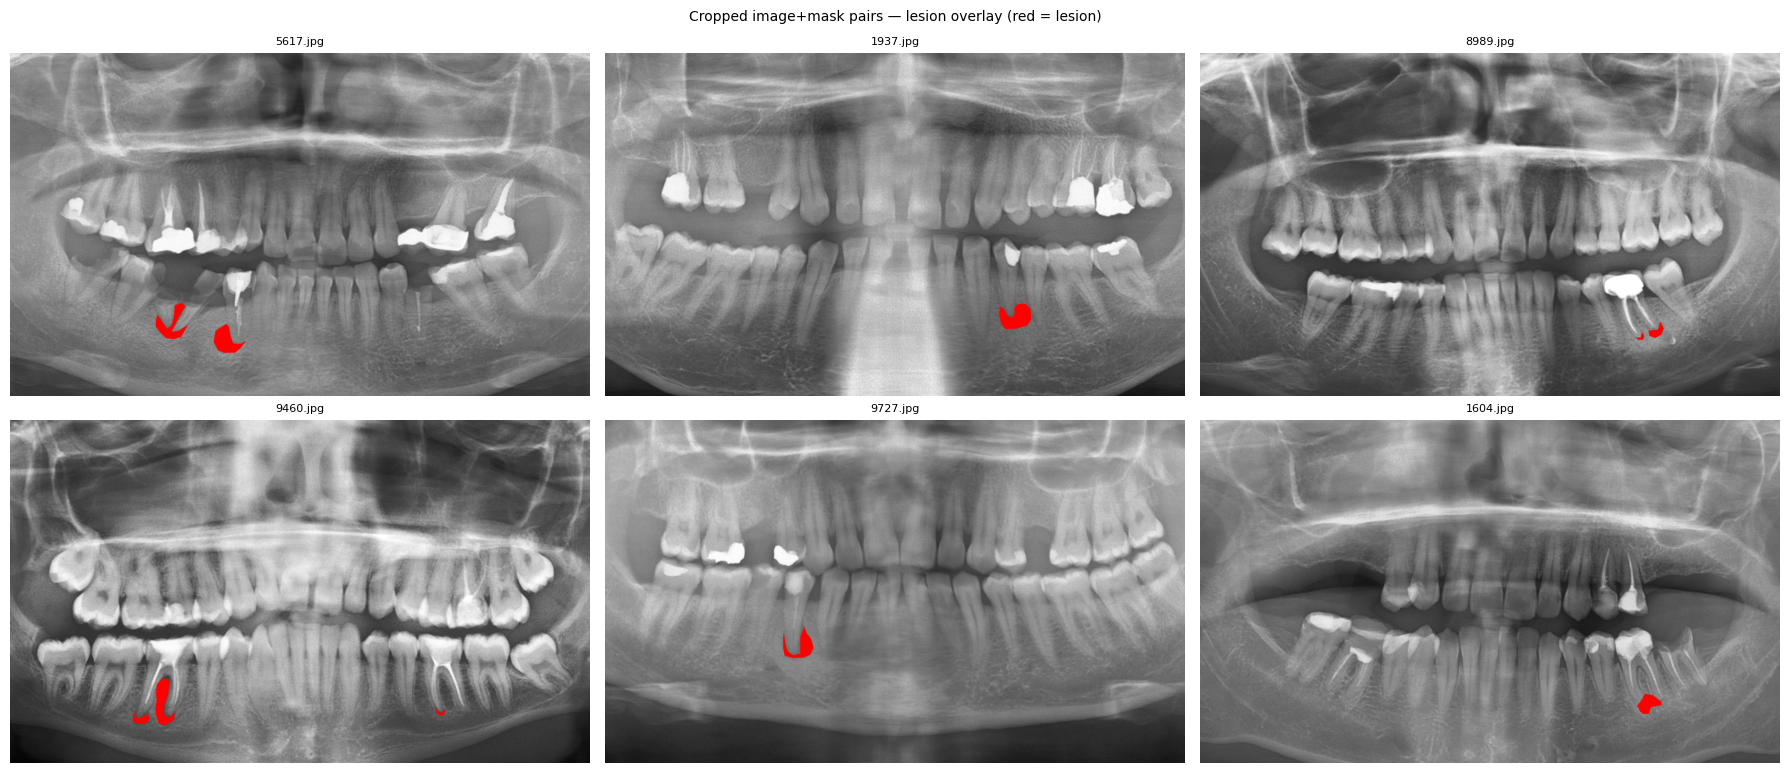

In [ ]:
# Spot check: display 6 random cropped image+mask pairs with lesion overlay.
# Confirm that lesions are still present and correctly aligned after cropping.

crop_image_files = sorted([
    f for f in os.listdir(CROP_IMAGES)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

sample = random.sample(crop_image_files, min(6, len(crop_image_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, fname in enumerate(sample):
    img_path  = os.path.join(CROP_IMAGES, fname)
    mask_fname = os.path.splitext(fname)[0] + '.png'
    mask_path = os.path.join(CROP_MASKS, mask_fname)

    with Image.open(img_path) as img, Image.open(mask_path) as mask:
        img_rgb  = np.array(img.convert('RGB'))
        mask_arr = np.array(mask)

        # Highlight lesion in red
        img_rgb[mask_arr > 127] = [255, 0, 0]

        axes[i].imshow(img_rgb)
        axes[i].set_title(fname, fontsize=8)
        axes[i].axis('off')

plt.suptitle('Cropped image+mask pairs — lesion overlay (red = lesion)', fontsize=10)
plt.tight_layout()
plt.show()

## 7. Class Balance Analysis

Before splitting the dataset and training the model, we analyze
the pixel-level class balance across all cropped masks.

This tells us:
- What percentage of pixels are lesion vs background
- How much the lesion coverage varies across images
- How many negative samples (all-black masks) we have

These numbers directly inform our loss function and training strategy.

  CLASS BALANCE REPORT

  Global pixel ratio
    Lesion pixels  : 2,268,450  (0.37%)
    Background px  : 618,900,336  (99.63%)
    Imbalance ratio: 1 : 273

  Per-image lesion coverage
    Mean   : 0.37%
    Median : 0.30%
    Min    : 0.00%
    Max    : 1.69%
    Std    : 0.27%

  Negative samples (all-black mask): 5


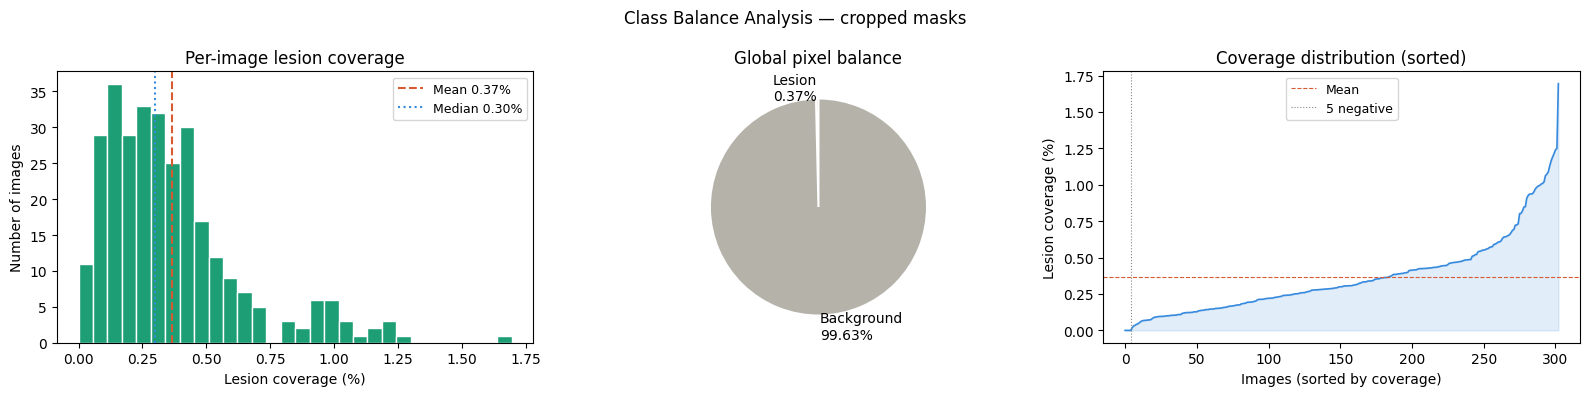

In [ ]:
import numpy as np

crop_mask_files = sorted([
    f for f in os.listdir(CROP_MASKS)
    if f.lower().endswith('.png')
])

total_pixels    = 0
total_lesion    = 0
per_image_ratios = []
empty_masks     = []

for fname in crop_mask_files:
    path = os.path.join(CROP_MASKS, fname)
    mask = np.array(Image.open(path).convert('L'))

    # Binarize: any pixel > 127 is lesion
    binary   = (mask > 127).astype(np.uint8)
    n_pixels = binary.size
    n_lesion = binary.sum()
    ratio    = n_lesion / n_pixels * 100

    total_pixels += n_pixels
    total_lesion += n_lesion
    per_image_ratios.append(ratio)

    if n_lesion == 0:
        empty_masks.append(fname)

per_image_ratios = np.array(per_image_ratios)
global_ratio     = total_lesion / total_pixels * 100
imbalance_ratio  = (total_pixels - total_lesion) / max(total_lesion, 1)

print("=" * 50)
print("  CLASS BALANCE REPORT")
print("=" * 50)
print(f"\n  Global pixel ratio")
print(f"    Lesion pixels  : {total_lesion:,}  ({global_ratio:.2f}%)")
print(f"    Background px  : {total_pixels - total_lesion:,}  ({100-global_ratio:.2f}%)")
print(f"    Imbalance ratio: 1 : {imbalance_ratio:.0f}")
print(f"\n  Per-image lesion coverage")
print(f"    Mean   : {per_image_ratios.mean():.2f}%")
print(f"    Median : {np.median(per_image_ratios):.2f}%")
print(f"    Min    : {per_image_ratios.min():.2f}%")
print(f"    Max    : {per_image_ratios.max():.2f}%")
print(f"    Std    : {per_image_ratios.std():.2f}%")
print(f"\n  Negative samples (all-black mask): {len(empty_masks)}")
print("=" * 50)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Class Balance Analysis — cropped masks", fontsize=12)

# 1. Histogram
ax = axes[0]
ax.hist(per_image_ratios, bins=30, color="#1D9E75", edgecolor="white")
ax.axvline(per_image_ratios.mean(),
           color="#D85A30", linestyle="--",
           label=f"Mean {per_image_ratios.mean():.2f}%")
ax.axvline(np.median(per_image_ratios),
           color="#378ADD", linestyle=":",
           label=f"Median {np.median(per_image_ratios):.2f}%")
ax.set_xlabel("Lesion coverage (%)")
ax.set_ylabel("Number of images")
ax.set_title("Per-image lesion coverage")
ax.legend(fontsize=9)

# 2. Pie chart
ax = axes[1]
ax.pie(
    [total_lesion, total_pixels - total_lesion],
    labels=[f"Lesion\n{global_ratio:.2f}%", f"Background\n{100-global_ratio:.2f}%"],
    colors=["#D85A30", "#B4B2A9"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Global pixel balance")

# 3. Sorted coverage curve
ax = axes[2]
sorted_ratios = np.sort(per_image_ratios)
ax.plot(sorted_ratios, color="#378ADD", linewidth=1.2)
ax.fill_between(range(len(sorted_ratios)), sorted_ratios, alpha=0.15, color="#378ADD")
ax.axhline(per_image_ratios.mean(),
           color="#D85A30", linestyle="--",
           linewidth=0.8, label="Mean")
if len(empty_masks) > 0:
    ax.axvline(len(empty_masks) - 1,
               color="#888780", linestyle=":",
               linewidth=0.8, label=f"{len(empty_masks)} negative")
ax.set_xlabel("Images (sorted by coverage)")
ax.set_ylabel("Lesion coverage (%)")
ax.set_title("Coverage distribution (sorted)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Train / Val / Test Split

We split the dataset into three subsets:
- Train : 70% — the model learns from these
- Val   : 15% — used during training to monitor overfitting
- Test  : 15% — held out until final evaluation, never seen during training

Images and masks are paired before shuffling to guarantee alignment.
random.seed(42) ensures the split is reproducible — same result every run.

Output: 06_dataset/train, val, test (each with images/ and masks/ subfolders)

In [ ]:
# Pair every image with its corresponding mask by filename,
# shuffle the pairs, then split and copy to 06_dataset.

import shutil

# Build paired list: (image_filename, mask_filename)
crop_image_files = sorted([
    f for f in os.listdir(CROP_IMAGES)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

pairs = []
missing_masks = []

for fname in crop_image_files:
    mask_fname = os.path.splitext(fname)[0] + '.png'
    mask_path  = os.path.join(CROP_MASKS, mask_fname)
    if os.path.exists(mask_path):
        pairs.append((fname, mask_fname))
    else:
        missing_masks.append(fname)

print(f"Total pairs found  : {len(pairs)}")
if missing_masks:
    print(f"⚠ Images with no matching mask: {len(missing_masks)}")
    for f in missing_masks:
        print(f"  {f}")

# Shuffle pairs together (never shuffle images and masks separately)
random.seed(42)
random.shuffle(pairs)

# Split
n_total = len(pairs)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

print(f"\nSplit summary:")
print(f"  Train : {len(train_pairs)}  ({len(train_pairs)/n_total*100:.1f}%)")
print(f"  Val   : {len(val_pairs)}   ({len(val_pairs)/n_total*100:.1f}%)")
print(f"  Test  : {len(test_pairs)}  ({len(test_pairs)/n_total*100:.1f}%)")

# Copy files to 06_dataset
def copy_pairs(pairs, img_dst_dir, mask_dst_dir):
    copied  = 0
    skipped = 0
    for img_fname, mask_fname in pairs:
        img_src  = os.path.join(CROP_IMAGES, img_fname)
        mask_src = os.path.join(CROP_MASKS,  mask_fname)
        img_dst  = os.path.join(img_dst_dir,  img_fname)
        mask_dst = os.path.join(mask_dst_dir, mask_fname)

        if os.path.exists(img_dst) and os.path.exists(mask_dst):
            skipped += 1
            continue

        shutil.copy2(img_src,  img_dst)
        shutil.copy2(mask_src, mask_dst)
        copied += 1
    return copied, skipped

splits = [
    (train_pairs, TRAIN_IMAGES, TRAIN_MASKS, 'Train'),
    (val_pairs,   VAL_IMAGES,   VAL_MASKS,   'Val'),
    (test_pairs,  TEST_IMAGES,  TEST_MASKS,  'Test'),
]

print()
for pairs_subset, img_dir, mask_dir, label in splits:
    copied, skipped = copy_pairs(pairs_subset, img_dir, mask_dir)
    print(f"  {label:6} — copied: {copied}  skipped: {skipped}")

print("\n✓ Dataset split complete.")

Total pairs found  : 303

Split summary:
  Train : 212  (70.0%)
  Val   : 45   (14.9%)
  Test  : 46  (15.2%)

  Train  — copied: 0  skipped: 212
  Val    — copied: 0  skipped: 45
  Test   — copied: 0  skipped: 46

✓ Dataset split complete.


In [ ]:
# Confirm file counts in each split folder.
# Also verify that no image appears in more than one split.

def count_files(directory):
    return len([
        f for f in os.listdir(directory)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

print("File counts per split:")
print(f"  Train — images: {count_files(TRAIN_IMAGES)}  masks: {count_files(TRAIN_MASKS)}")
print(f"  Val   — images: {count_files(VAL_IMAGES)}   masks: {count_files(VAL_MASKS)}")
print(f"  Test  — images: {count_files(TEST_IMAGES)}  masks: {count_files(TEST_MASKS)}")

# Check for overlap between splits
train_set = set(os.listdir(TRAIN_IMAGES))
val_set   = set(os.listdir(VAL_IMAGES))
test_set  = set(os.listdir(TEST_IMAGES))

train_val_overlap  = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap   = val_set   & test_set

print("\nOverlap check:")
if not any([train_val_overlap, train_test_overlap, val_test_overlap]):
    print("  ✓ No overlap between splits — clean separation confirmed.")
else:
    if train_val_overlap:
        print(f"  ⚠ Train/Val overlap: {len(train_val_overlap)} files")
    if train_test_overlap:
        print(f"  ⚠ Train/Test overlap: {len(train_test_overlap)} files")
    if val_test_overlap:
        print(f"  ⚠ Val/Test overlap: {len(val_test_overlap)} files")

File counts per split:
  Train — images: 212  masks: 212
  Val   — images: 45   masks: 45
  Test  — images: 46  masks: 46

Overlap check:
  ✓ No overlap between splits — clean separation confirmed.


## 9. Model Training

Architecture  : U-Net
Loss function : Dice + Binary Cross-Entropy (combined)
Primary metric: Dice coefficient
Augmentation  : horizontal flip, rotation, brightness/contrast
Framework     : TensorFlow / Keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

# Confirm GPU is available
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 9.1 Dataset Pipeline

Loads cropped image+mask pairs from 06_dataset.
Applies augmentation to the training set only.
All images are normalized to [0, 1] range before being fed to the model.

In [ ]:
# Input size — resized from original crop size to fit GPU memory
# Original crop: 1862 x 1101
ORIG_WIDTH  = 1862
ORIG_HEIGHT = 1101

IMG_HEIGHT   = 768
IMG_WIDTH    = 1024
IMG_CHANNELS = 1  # grayscale

# Training hyperparameters
BATCH_SIZE    = 2
EPOCHS        = 150
LEARNING_RATE = 1e-4

print(f"Input shape   : {IMG_HEIGHT} x {IMG_WIDTH} x {IMG_CHANNELS}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Epochs        : {EPOCHS}")
print(f"Learning rate : {LEARNING_RATE}")
print(f"\nOriginal crop size : {ORIG_WIDTH} x {ORIG_HEIGHT}")
print(f"Resize ratio       : {IMG_WIDTH/ORIG_WIDTH:.2f} x {IMG_HEIGHT/ORIG_HEIGHT:.2f}")
print(f"Pixel area preserved: {(IMG_WIDTH*IMG_HEIGHT)/(ORIG_WIDTH*ORIG_HEIGHT)*100:.1f}%")

Input shape   : 768 x 1024 x 1
Batch size    : 2
Epochs        : 150
Learning rate : 0.0001

Original crop size : 1862 x 1101
Resize ratio       : 0.55 x 0.70
Pixel area preserved: 38.4%


### 9.2 Data Loader

Loads image+mask pairs from disk.
Resizes to model input size (768x576).
Normalizes pixel values to [0, 1].
Augmentation applied to training set only.

In [ ]:
def load_image_mask(img_path, mask_path):
    """Load a single image+mask pair, resize and normalize."""

    # Load image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0  # normalize to [0, 1]

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH],
                           method='nearest')  # no interpolation for masks
    mask = tf.cast(mask, tf.float32) / 255.0  # normalize to [0, 1]
    mask = tf.round(mask)  # ensure binary: 0 or 1

    return img, mask


def augment(img, mask):
    """Apply identical augmentation to image and mask."""

    # Horizontal flip
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # Vertical flip (less aggressive, but useful for dental X-rays)
    if tf.random.uniform(()) > 0.8:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # Brightness adjustment — image only, never mask
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)  # keep values in [0, 1]

    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, shuffle=False):
    """Build a tf.data pipeline for a given split."""

    img_files = sorted([
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith('.png')
    ])

    assert len(img_files) == len(mask_files), \
        f"Mismatch: {len(img_files)} images vs {len(mask_files)} masks"

    dataset = tf.data.Dataset.from_tensor_slices((img_files, mask_files))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(img_files), seed=42)

    dataset = dataset.map(load_image_mask,
                          num_parallel_calls=tf.data.AUTOTUNE)

    if augment_data:
        dataset = dataset.map(augment,
                              num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset, len(img_files)


# Build all three splits
train_ds, n_train = build_dataset(TRAIN_IMAGES, TRAIN_MASKS,
                                   augment_data=True, shuffle=True)
val_ds,   n_val   = build_dataset(VAL_IMAGES,   VAL_MASKS)
test_ds,  n_test  = build_dataset(TEST_IMAGES,  TEST_MASKS)

print(f"Train batches : {len(train_ds)}  ({n_train} images)")
print(f"Val batches   : {len(val_ds)}    ({n_val} images)")
print(f"Test batches  : {len(test_ds)}   ({n_test} images)")
print("\n✓ Data pipeline ready.")

Train batches : 106  (212 images)
Val batches   : 23    (45 images)
Test batches  : 23   (46 images)

✓ Data pipeline ready.


### 9.3 U-Net Architecture

Encoder: 4 blocks, each doubling the number of filters
Bottleneck: deepest layer, highest number of filters
Decoder: 4 blocks, each halving back with skip connections from encoder
Output: single channel sigmoid activation → pixel-wise probability [0,1]

In [ ]:
def conv_block(x, filters, dropout_rate=0.0):
    """Two consecutive Conv2D + BatchNorm + ReLU layers."""
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def encoder_block(x, filters, dropout_rate=0.0):
    """Conv block + MaxPooling. Returns skip connection and downsampled output."""
    skip = conv_block(x, filters, dropout_rate)
    pool = layers.MaxPooling2D(2)(skip)
    return skip, pool


def decoder_block(x, skip, filters):
    """Upsample + concatenate skip connection + conv block."""
    x = layers.UpSampling2D(2)(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet(input_shape, filters=[32, 64, 128, 256], dropout_rate=0.3):
    """
    Build U-Net model.
    input_shape: (height, width, channels)
    filters: number of filters at each encoder level
    """
    inputs = layers.Input(shape=input_shape)

    # Encoder
    skip1, p1 = encoder_block(inputs, filters[0])
    skip2, p2 = encoder_block(p1,     filters[1])
    skip3, p3 = encoder_block(p2,     filters[2], dropout_rate)
    skip4, p4 = encoder_block(p3,     filters[3], dropout_rate)

    # Bottleneck
    bottleneck = conv_block(p4, filters[3] * 2, dropout_rate)

    # Decoder
    d1 = decoder_block(bottleneck, skip4, filters[3])
    d2 = decoder_block(d1,         skip3, filters[2])
    d3 = decoder_block(d2,         skip2, filters[1])
    d4 = decoder_block(d3,         skip1, filters[0])

    # Output layer — sigmoid for binary segmentation
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d4)

    model = Model(inputs, outputs, name='unet')
    return model


# Build model
model = build_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    filters=[32, 64, 128, 256],
    dropout_rate=0.3
)

model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 768, 1024, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 768, 1024, │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 768, 1024, │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 768, 1024, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 768, 1024, │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 768, 1024, │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 768, 1024, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 384, 512,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 384, 512,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 512,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 384, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 384, 512,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 512,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 384, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 192, 256,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 192, 256,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 256,  │        512 │ conv2d_4[0][0]  

 Total params: 7,857,857 (29.98 MB)

 Trainable params: 7,851,969 (29.95 MB)

 Non-trainable params: 5,888 (23.00 KB)

### 9.4 Loss Function and Metrics

We use a combined Dice + Binary Cross-Entropy loss.

- BCE component: stable gradients, pixel-wise
- Dice component: directly optimizes overlap between prediction and ground truth
- Combined: best of both, standard approach in medical image segmentation

Primary metric: Dice coefficient (higher = better, 1.0 = perfect overlap)

In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice coefficient — measures overlap between prediction and ground truth.
    Range: 0 (no overlap) to 1 (perfect overlap).
    smooth: small value to avoid division by zero.
    """
    y_true_flat = tf.keras.backend.flatten(y_true)
    y_pred_flat = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    dice = (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) + smooth
    )
    return dice


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    """
    Combined loss: 50% BCE + 50% Dice.
    BCE handles per-pixel stability, Dice optimizes overlap.
    pos_weight=273 addresses the 1:273 class imbalance.
    """
    # Squeeze channel dimension: [batch, H, W, 1] → [batch, H, W]
    y_true_sq = tf.squeeze(y_true, axis=-1)
    y_pred_sq = tf.squeeze(y_pred, axis=-1)

    # Weighted BCE — compute manually to avoid shape issues
    pos_weight = 273.0
    bce = tf.nn.sigmoid_cross_entropy_with_logits(
        labels=y_true_sq,
        logits=tf.math.log(y_pred_sq / (1.0 - y_pred_sq + 1e-7) + 1e-7)
    )
    bce_weighted = bce * (y_true_sq * pos_weight + (1 - y_true_sq))
    bce_mean = tf.reduce_mean(bce_weighted)

    dice = dice_loss(y_true, y_pred)

    return 0.5 * bce_mean + 0.5 * dice


# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coefficient]
)

print("Model compiled successfully.")
print(f"Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"Loss function : BCE (pos_weight=273) + Dice combined")
print(f"Primary metric: Dice coefficient")

Model compiled successfully.
Optimizer     : Adam (lr=0.0001)
Loss function : BCE (pos_weight=273) + Dice combined
Primary metric: Dice coefficient


### 9.5 Training

Callbacks:
- ModelCheckpoint: saves the best model based on val_dice_coefficient
- EarlyStopping: stops training if val_dice_coefficient doesn't improve
- ReduceLROnPlateau: reduces learning rate when training plateaus
- CSVLogger: saves training history to logs folder

In [ ]:
import os

# Callback 1: save best model based on validation Dice
checkpoint_path = os.path.join(MODELS, 'best_model.keras')
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_dice_coefficient',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Callback 2: stop early if no improvement for 15 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_dice_coefficient',
    mode='max',
    patience=15,
    verbose=1,
    restore_best_weights=True
)

# Callback 3: reduce learning rate when stuck
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_dice_coefficient',
    mode='max',
    factor=0.5,       # halve the learning rate
    patience=7,
    min_lr=1e-7,
    verbose=1
)

# Callback 4: save training history to CSV
csv_logger = tf.keras.callbacks.CSVLogger(
    os.path.join(LOGS, 'training_log.csv'),
    append=False
)

# Train
print("Starting training...")
print(f"  Best model will be saved to: {checkpoint_path}")
print()

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping, reduce_lr, csv_logger]
)

Starting training...
  Best model will be saved to: /content/drive/MyDrive/2026_white_lesion_detection_project/07_outputs/models/best_model.keras

Epoch 1/150
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - dice_coefficient: 0.0112 - loss: 1.0485
Epoch 1: val_dice_coefficient improved from None to 0.00775, saving model to /content/drive/MyDrive/2026_white_lesion_detection_project/07_outputs/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2026_white_lesion_detection_project/07_outputs/models/best_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 146s 775ms/step - dice_coefficient: 0.0133 - loss: 1.0104 - val_dice_coefficient: 0.0078 - val_loss: 1.2953 - learning_rate: 1.0000e-04
Epoch 2/150
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - dice_coefficient: 0.0152 - loss: 0.9174
Epoch 2: val_dice_coefficient did not improve from 0.00775
106/106 ━━━━━━━━━━━━━━━━━━━━ 67s 630ms/step - dice_coefficient: 0.0167 - loss: 0.9264 - val_dice_coefficient: 0.0077 - val_loss: 2.3759

### 9.6 Training curves

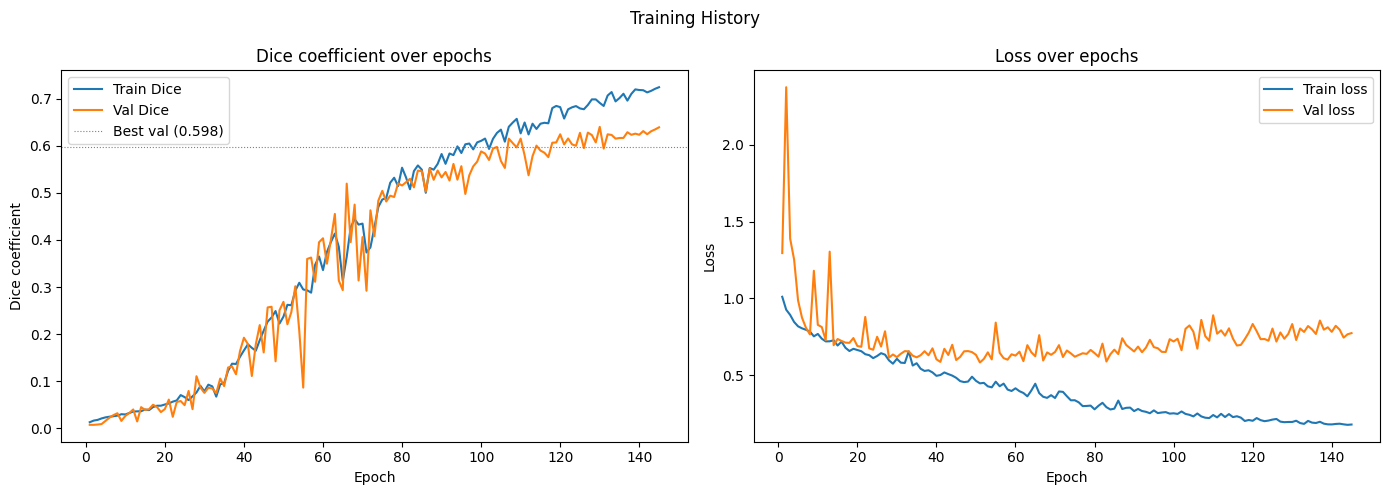

In [ ]:
import pandas as pd

# Load training log
log_path = os.path.join(LOGS, 'training_log.csv')
history_df = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=12)

# Dice coefficient
axes[0].plot(history_df['epoch']+1,
             history_df['dice_coefficient'], label='Train Dice')
axes[0].plot(history_df['epoch']+1,
             history_df['val_dice_coefficient'], label='Val Dice')
axes[0].axhline(0.598, color='gray', linestyle=':', linewidth=0.8,
                label='Best val (0.598)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Dice coefficient')
axes[0].set_title('Dice coefficient over epochs')
axes[0].legend()

# Loss
axes[1].plot(history_df['epoch']+1,
             history_df['loss'], label='Train loss')
axes[1].plot(history_df['epoch']+1,
             history_df['val_loss'], label='Val loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

### 9.7 Test Set Evaluation

Final evaluation on 46 held-out test images.
The model loaded here is the best checkpoint (highest val Dice during training).

In [ ]:
# Load best saved model
best_model = tf.keras.models.load_model(
    os.path.join(MODELS, 'best_model.keras'),
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coefficient': dice_coefficient
    }
)

# Evaluate on test set
print("Evaluating on test set...")
results = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest loss          : {results[0]:.4f}")
print(f"Test Dice          : {results[1]:.4f}")

Evaluating on test set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 474ms/step - dice_coefficient: 0.5752 - loss: 1.4713

Test loss          : 1.4713
Test Dice          : 0.5752


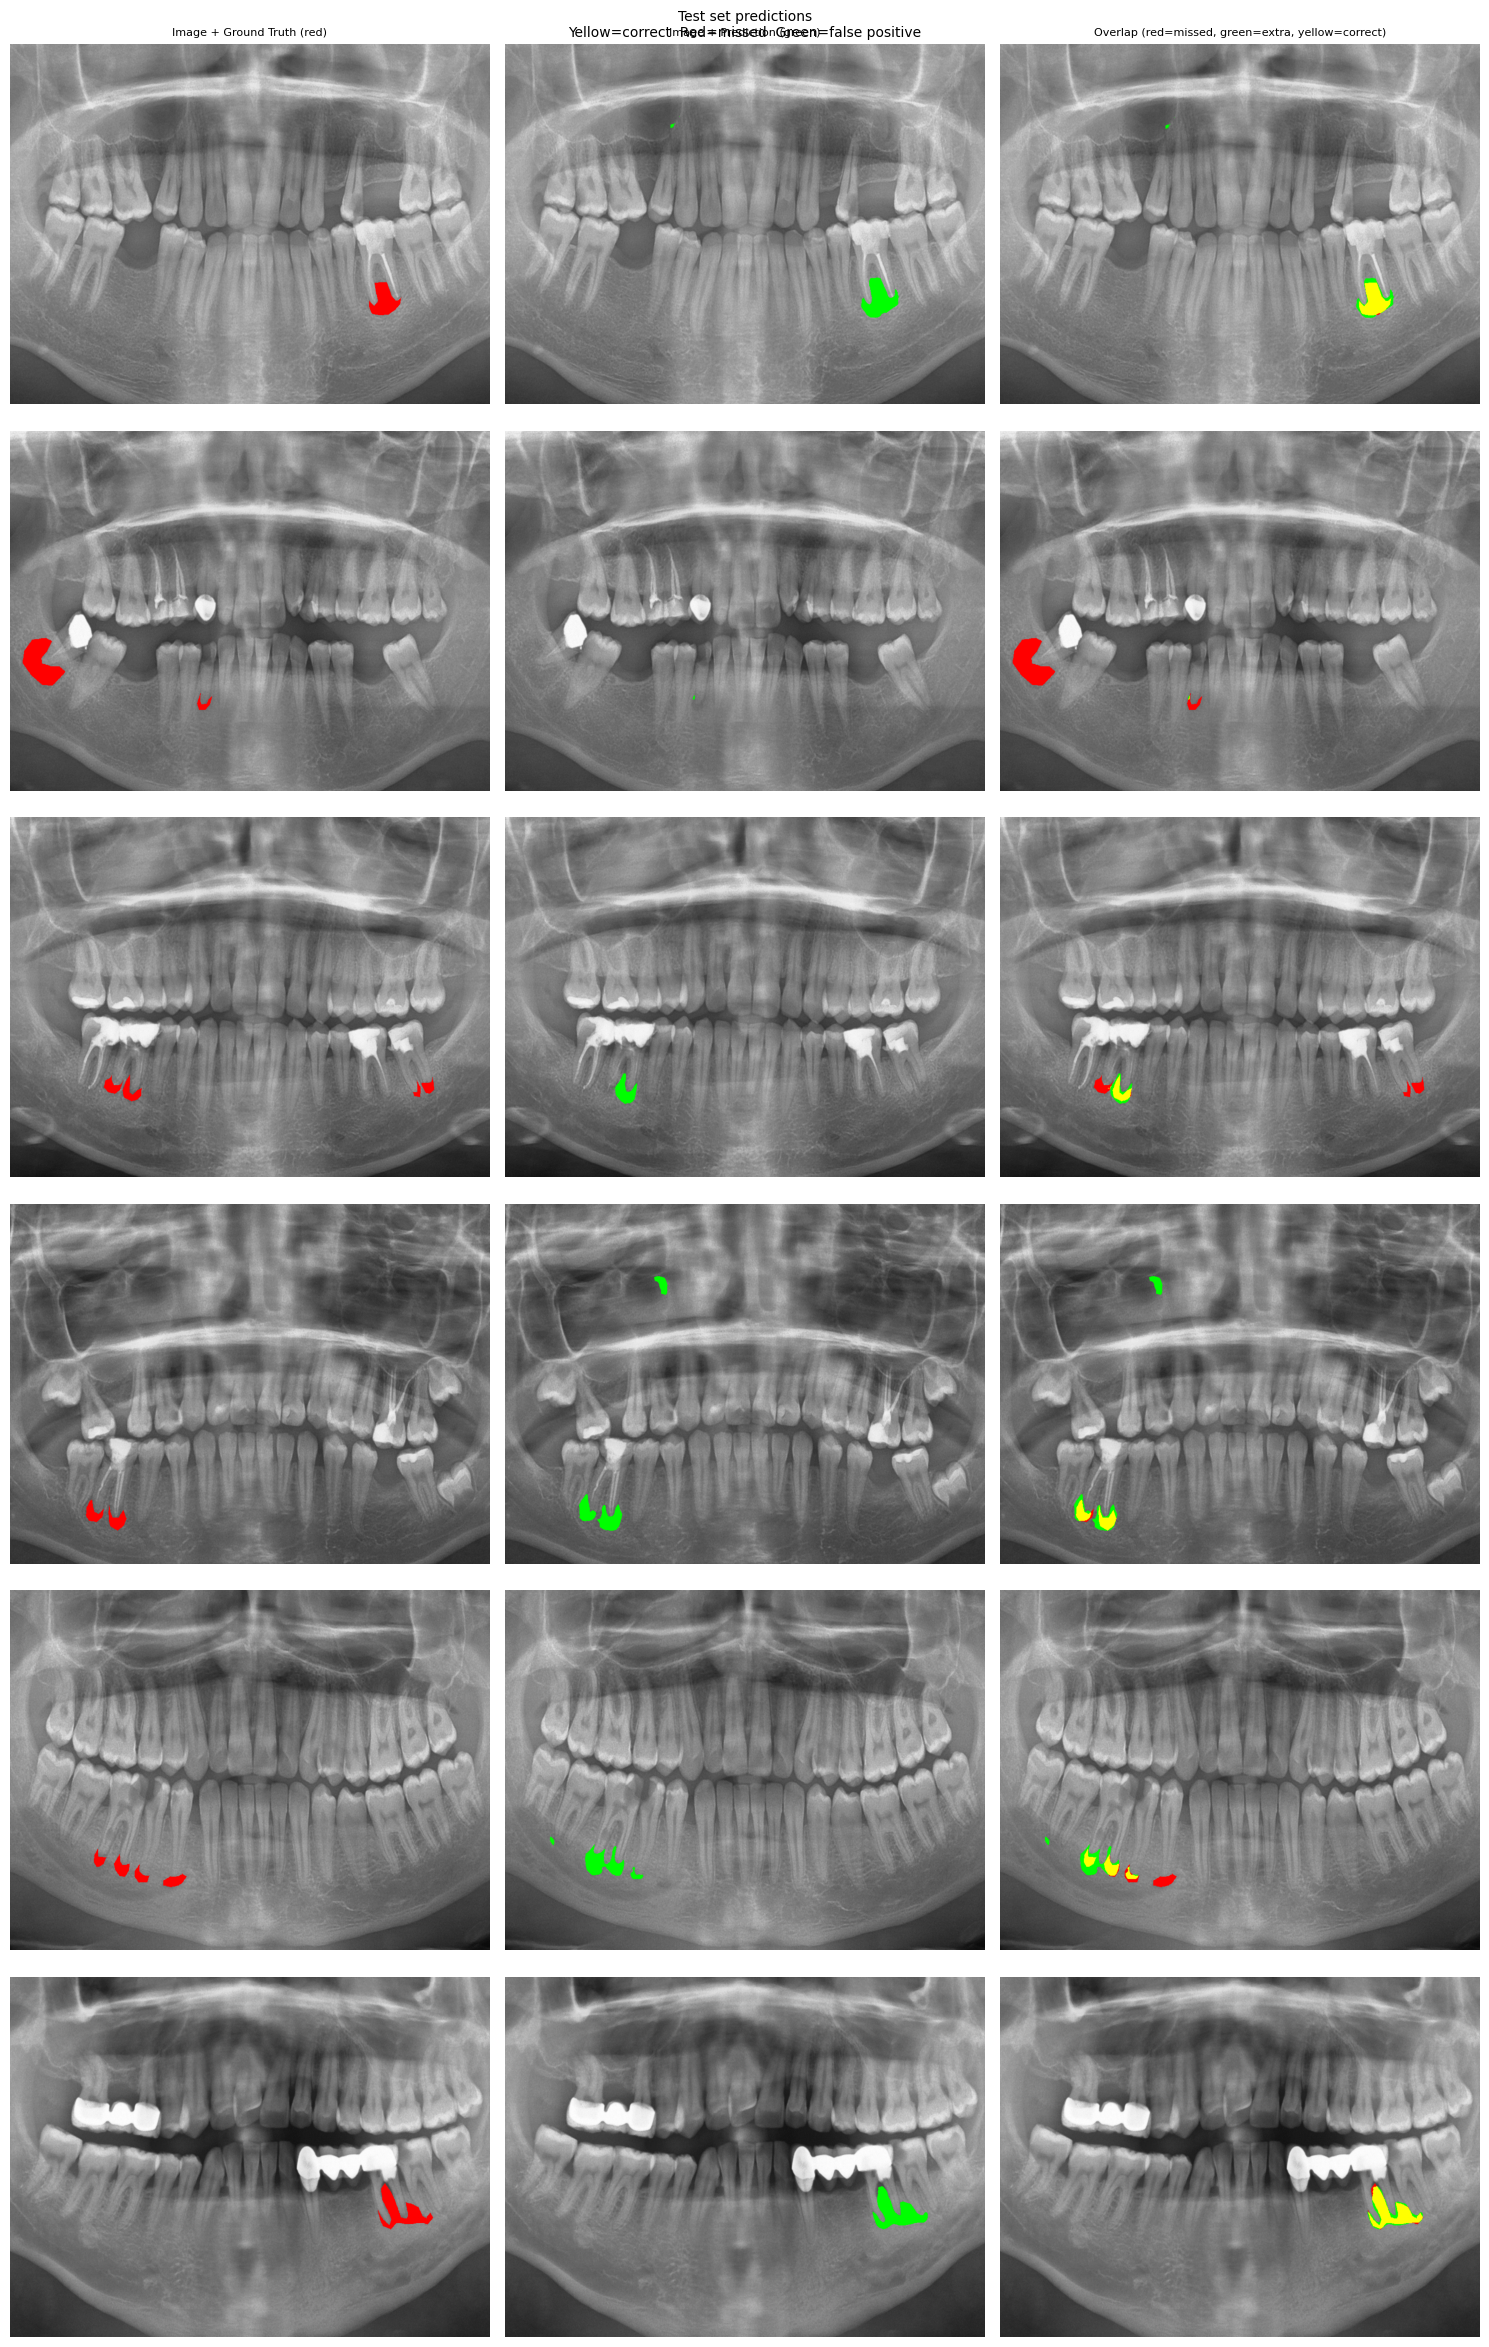

In [ ]:
# Visualize predictions on 6 random test images.
# Red = ground truth, Green = model prediction, Yellow = overlap

test_image_files = sorted([
    f for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

sample = random.sample(test_image_files, min(6, len(test_image_files)))

fig, axes = plt.subplots(6, 3, figsize=(15, 24))
col_titles = ['Image + Ground Truth (red)',
              'Image + Prediction (green)',
              'Overlap (red=missed, green=extra, yellow=correct)']

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=8)

for i, fname in enumerate(sample):
    img_path  = os.path.join(TEST_IMAGES, fname)
    mask_fname = os.path.splitext(fname)[0] + '.png'
    mask_path = os.path.join(TEST_MASKS, mask_fname)

    # Load and preprocess
    with Image.open(img_path) as img, Image.open(mask_path) as mask:
        img_gray  = np.array(img.convert('L'))
        mask_true = np.array(mask.convert('L'))

    # Prepare for model input
    img_input = tf.image.resize(
        img_gray[..., np.newaxis], [IMG_HEIGHT, IMG_WIDTH])
    img_input = tf.cast(img_input, tf.float32) / 255.0
    img_input = img_input[np.newaxis, ...]  # add batch dimension

    # Predict
    pred = best_model.predict(img_input, verbose=0)[0, :, :, 0]
    pred_binary = (pred > 0.5).astype(np.uint8)

    # Resize ground truth mask to model input size
    mask_resized = np.array(
        Image.fromarray(mask_true).resize(
            (IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)) > 127

    # Build RGB overlays
    img_display = np.array(
        Image.fromarray(img_gray).resize((IMG_WIDTH, IMG_HEIGHT)))
    img_rgb = np.stack([img_display]*3, axis=-1)

    # Col 1: ground truth in red
    gt_overlay = img_rgb.copy()
    gt_overlay[mask_resized] = [255, 0, 0]

    # Col 2: prediction in green
    pred_overlay = img_rgb.copy()
    pred_overlay[pred_binary == 1] = [0, 255, 0]

    # Col 3: overlap analysis
    overlap = img_rgb.copy()
    overlap[mask_resized & (pred_binary == 1)] = [255, 255, 0]   # correct — yellow
    overlap[mask_resized & (pred_binary == 0)] = [255, 0, 0]     # missed — red
    overlap[(~mask_resized) & (pred_binary == 1)] = [0, 255, 0]  # extra — green

    axes[i, 0].imshow(gt_overlay)
    axes[i, 1].imshow(pred_overlay)
    axes[i, 2].imshow(overlap)

    for j in range(3):
        axes[i, j].set_ylabel(fname, fontsize=7)
        axes[i, j].axis('off')

plt.suptitle('Test set predictions\nYellow=correct  Red=missed  Green=false positive',
             fontsize=10)
plt.tight_layout()
plt.show()

### 9.8 Test-Time Augmentation (TTA)

Instead of predicting once on the original image, we predict on multiple
augmented versions and average the results. No retraining needed.

Augmentations used:
- Original
- Horizontal flip
- Brightness +10%
- Brightness -10%

Expected gain: +0.02–0.05 Dice over single-pass prediction.

In [ ]:
def predict_tta(model, img_array):
    """
    Run inference on multiple augmented versions of the image
    and return the averaged prediction.
    img_array: numpy array, shape (H, W, 1), values in [0, 1]
    """
    preds = []

    # 1. Original
    inp = img_array[np.newaxis, ...]
    preds.append(model.predict(inp, verbose=0)[0, :, :, 0])

    # 2. Horizontal flip → predict → flip back
    flipped = np.fliplr(img_array)
    inp = flipped[np.newaxis, ...]
    pred_flipped = model.predict(inp, verbose=0)[0, :, :, 0]
    preds.append(np.fliplr(pred_flipped))

    # 3. Brightness +10%
    bright_up = np.clip(img_array * 1.1, 0, 1)
    inp = bright_up[np.newaxis, ...]
    preds.append(model.predict(inp, verbose=0)[0, :, :, 0])

    # 4. Brightness -10%
    bright_down = np.clip(img_array * 0.9, 0, 1)
    inp = bright_down[np.newaxis, ...]
    preds.append(model.predict(inp, verbose=0)[0, :, :, 0])

    # Average all predictions
    avg_pred = np.mean(preds, axis=0)
    return avg_pred


# Run TTA on entire test set and compute Dice
test_image_files = sorted([
    f for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

dice_scores_single = []
dice_scores_tta    = []

for fname in test_image_files:
    img_path   = os.path.join(TEST_IMAGES, fname)
    mask_fname = os.path.splitext(fname)[0] + '.png'
    mask_path  = os.path.join(TEST_MASKS, mask_fname)

    # Load image
    with Image.open(img_path) as img:
        img_gray = np.array(img.convert('L'))

    img_resized = np.array(
        Image.fromarray(img_gray).resize((IMG_WIDTH, IMG_HEIGHT))
    ).astype(np.float32) / 255.0
    img_input = img_resized[..., np.newaxis]  # (H, W, 1)

    # Load mask
    with Image.open(mask_path) as mask:
        mask_arr = np.array(mask.convert('L'))
    mask_resized = (np.array(
        Image.fromarray(mask_arr).resize(
            (IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
    ) > 127).astype(np.float32)

    # Single pass prediction
    single_pred = best_model.predict(
        img_input[np.newaxis, ...], verbose=0)[0, :, :, 0]
    single_binary = (single_pred > 0.5).astype(np.float32)

    # TTA prediction
    tta_pred = predict_tta(best_model, img_input)
    tta_binary = (tta_pred > 0.5).astype(np.float32)

    # Dice per image
    def dice_np(y_true, y_pred, smooth=1e-6):
        intersection = (y_true * y_pred).sum()
        return (2 * intersection + smooth) / (
            y_true.sum() + y_pred.sum() + smooth)

    dice_scores_single.append(dice_np(mask_resized, single_binary))
    dice_scores_tta.append(dice_np(mask_resized, tta_binary))

print("=" * 40)
print("  TTA RESULTS")
print("=" * 40)
print(f"  Single pass Dice : {np.mean(dice_scores_single):.4f}")
print(f"  TTA Dice         : {np.mean(dice_scores_tta):.4f}")
print(f"  Improvement      : +{np.mean(dice_scores_tta) - np.mean(dice_scores_single):.4f}")
print("=" * 40)

  TTA RESULTS
  Single pass Dice : 0.5991
  TTA Dice         : 0.6102
  Improvement      : +0.0112


### 9.9 Precision, Recall and F1 — Test Set

Computed per image, then averaged.

- Precision : of all pixels predicted as lesion, how many are correct?
- Recall    : of all actual lesion pixels, how many did we detect?
- F1        : harmonic mean of precision and recall

In [ ]:
precision_scores = []
recall_scores    = []
f1_scores        = []

for fname in test_image_files:
    img_path   = os.path.join(TEST_IMAGES, fname)
    mask_fname = os.path.splitext(fname)[0] + '.png'
    mask_path  = os.path.join(TEST_MASKS, mask_fname)

    # Load and preprocess image
    with Image.open(img_path) as img:
        img_gray = np.array(img.convert('L'))
    img_resized = np.array(
        Image.fromarray(img_gray).resize((IMG_WIDTH, IMG_HEIGHT))
    ).astype(np.float32) / 255.0
    img_input = img_resized[..., np.newaxis]

    # Load and resize mask
    with Image.open(mask_path) as mask:
        mask_arr = np.array(mask.convert('L'))
    mask_resized = (np.array(
        Image.fromarray(mask_arr).resize(
            (IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
    ) > 127).astype(np.float32)

    # TTA prediction
    tta_pred   = predict_tta(best_model, img_input)
    tta_binary = (tta_pred > 0.5).astype(np.float32)

    # Metrics
    tp = (tta_binary * mask_resized).sum()
    fp = (tta_binary * (1 - mask_resized)).sum()
    fn = ((1 - tta_binary) * mask_resized).sum()

    smooth = 1e-6
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    f1        = 2 * precision * recall / (precision + recall + smooth)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

print("=" * 50)
print("  FINAL METRICS — Test Set (with TTA)")
print("=" * 50)
print(f"  Dice      : {np.mean(dice_scores_tta):.4f}")
print(f"  Precision : {np.mean(precision_scores):.4f}")
print(f"  Recall    : {np.mean(recall_scores):.4f}")
print(f"  F1        : {np.mean(f1_scores):.4f}")
print("=" * 50)
print()
print("  Literature comparison (InceptionResNetV2):")
print("  Dice      : N/A")
print("  Precision : 0.281")
print("  Recall    : 0.814")
print("  F1        : 0.418")
print("=" * 50)

  FINAL METRICS — Test Set (with TTA)
  Dice      : 0.6102
  Precision : 0.6050
  Recall    : 0.7430
  F1        : 0.6102

  Literature comparison (InceptionResNetV2):
  Dice      : N/A
  Precision : 0.281
  Recall    : 0.814
  F1        : 0.418
